# Ensemble experiments with random Boolean networks

This tutorial demonstrates how BoolForge's ability to generate **random Boolean 
networks with controlled structural and functional properties** is essential 
for many types of studies. Specifically, it enables:

1. **Null model comparisons**  
   Are biological networks structurally or dynamically different from random networks?

2. **Ensemble studies**  
   How do structural properties such as degree or canalization affect network dynamics?

## What you will learn
In this tutorial you will learn how to generate random Boolean networks with:

- specific structural properties (e.g., degree, degree distribution, strongly connected),
- prescribed functional properties (e.g., canalization, bias),

It is strongly recommended to complete Tutorials 4 and 5 on random function generation first.

## Setup

In [1]:
import boolforge as bf
import numpy as np
import matplotlib.pyplot as plt

## Biased NK Kauffman networks

One of the classical models of complex systems is the **NK random Boolean network**
introduced by Stuart Kauffman.

In this model:

- The network contains N nodes.
- Each node is regulated by k inputs.
- Each update function is generated randomly with *bias* $p$, i.e.

  - probability of output 1: `p`
  - probability of output 0: `1-p`

A key theoretical result due to Derrida and Pomeau predicts how a single-node perturbation
propagates in large random Boolean networks. They showed that if two network states differ in one node, 
the expected number of differences after one update step is $2kp(1-p)$.

If this value is

- $< 1$, then perturbations decrease on average (ordered regime)
- $> 1$, then perturbations increase on average (chaotic regime)
- $= 1$, then perturbations remain on average of equal size (critical boundary)

The expected number of propagated perturbations is called the **Derrida value**.

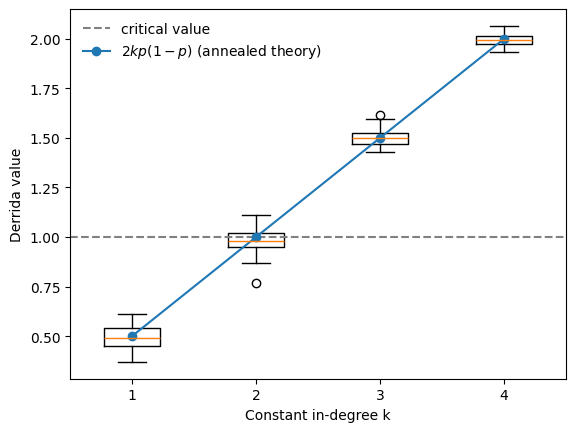

In [2]:
N = 100          # network size
ks = range(1,5)  # constant in-degree
n_networks = 50  # ensemble size
p = 0.5          # bias p: probability of ones in truth table

derrida_values = []
for k in ks:
    derrida_values.append([])
    for _ in range(n_networks):
        bn = bf.random_network(N, k, bias = p, allow_degenerate_functions=True)
        derrida_values[-1].append( bn.get_derrida_value(exact=True) )

plt.boxplot(derrida_values, positions=list(ks))
plt.axhline(1, linestyle="--", color="gray", label="critical value")
plt.plot(ks, [2*k*p*(1-p) for k in ks], "o-", label=r"$2kp(1-p)$ (annealed theory)")
plt.xlabel("Constant in-degree k")
plt.ylabel("Derrida value")
plt.legend(frameon=False)

The numerical results closely follow the theoretical prediction $2kp(1-p)$
derived under the **annealed approximation**. 
The phase transition occurs when the Derrida value crosses 1.

For unbiased Boolean functions (with bias $p=0.5$), the theory predicts the
critical connectivity $k=2$.

## BoolForge philosophy: non-degenerate regulatory functions

The classical NK model assumes that a Boolean function with $k$ inputs may
**not actually depend on all of them**. Such functions are called **degenerate**.

While this assumption is natural in statistical physics models (e.g. spin
glasses), it is biologically questionable. 
In gene regulatory networks, an input typically represents a *specific
regulatory interaction*. If a transcription factor does not affect the
gene, it should not appear as an input in the first place.
**Therefore BoolForge assumes non-degenerate Boolean functions by default.**

Degeneracy occurs frequently for small input sizes:

- $k=1$: 2 out of 4 functions are degenerate (50%)
- $k=2$: 6 out of 16 functions are degenerate
- larger $k$: degeneracy becomes increasingly rare

Disallowing degenerate functions therefore mainly affects **sparse networks**,
precisely the regime most biological networks operate in (typical average
in-degree $approx$ 2-3).

We now repeat the previous experiment **disallowing degenerate functions**.

The resilience of Boolean networks to perturbations critically depends on the bias p,
which can be seen by varying this parameter. Moreover, the classical result assumes that
Boolean network update rules may be degenerate. If we disallow this, the results change
substantially.

## BoolForge philosophy
However, he assumed that a Boolean function in k inputs may be degenerate and not actually
depend on all its inputs. While this makes sense physically, when thinking of spin glasses,
it does not make much sense biologically, e.g. Either a TF regulates a gene or is does not.
**Therefore, any random function and network sampler in BoolForge assumes, by default, that
functions are non-degenerate**.

Degeneracy randomly occurs predominarnly for low-input functions: Two out four (50%) of 
1-input functions are degenerate. This fraction decreases to 6/16, ... for n=2,3,... 
Not allowing degeneracy therefore affects primarily results for sparse random Boolean networks,
specifically the regime most biological networks operate in (they have an average in-degree of around 2.5).

Rerunning the above analysis, when disallowing degenerate functions, exemplifies the differences.

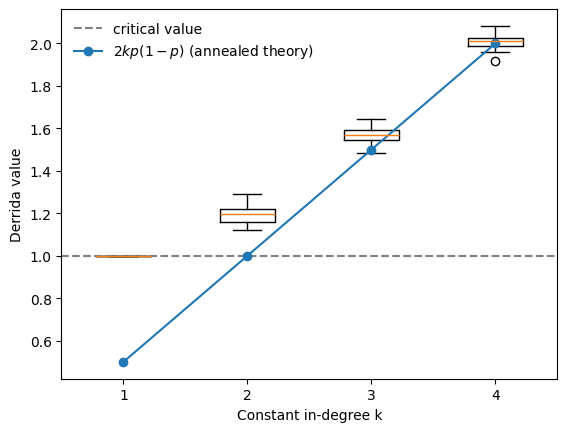

In [3]:
derrida_values = []
for k in ks:
    derrida_values.append([])
    for _ in range(n_networks):
        bn = bf.random_network(N, k, bias = p, allow_degenerate_functions=False)
        derrida_values[-1].append( bn.get_derrida_value(exact=True) )

plt.boxplot(derrida_values, positions=list(ks))
plt.axhline(1, linestyle="--", color="gray", label="critical value")
plt.plot(ks, [2*k*p*(1-p) for k in ks], "o-", label=r"$2kp(1-p)$ (annealed theory)")
plt.xlabel("Constant in-degree k")
plt.ylabel("Derrida value")
plt.legend(frameon=False)

The behavior changes substantially. For *unbiased, non-degenerate Boolean networks 
(with bias $p=0.5$)* the phase transition occurs already at $k=1$,
rather than $k=2$, as predicted by the classical NK theory.

This illustrates how biologically motivated modeling assumptions
can significantly affect the predicted dynamical regime of Boolean networks.

## Random networks with prescribed canalization

A major advantage of BoolForge is its ability to generate Boolean functions
with **controlled canalization properties**. This is important because canalization 
is a common feature of biological regulatory networks.

To display the impact of the canalizing layer structure, we generate
ensembles of Boolean networks of fixed size and fixed in-degree, which are governed
by nested canalizing functions of variable layer structure.

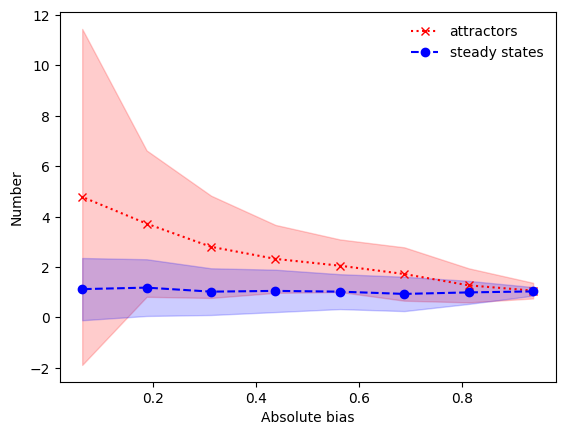

In [4]:
N = 12           # network size
n = 5            # constant in-degree
n_networks = 100 # ensemble size

all_hamming = np.arange(1, 2 ** (n - 1), 2)
all_abs_bias = 2 * np.abs(all_hamming/2**n - 0.5)

number_attractors = []
number_steady_states = []
for i, w in enumerate(all_hamming):
    layer_structure = bf.hamming_weight_to_ncf_layer_structure(n, w)
    number_attractors.append([])
    number_steady_states.append([])
    for _ in range(n_networks):
        bn = bf.random_network(N, n, layer_structure=layer_structure)
        attr_info = bn.get_attractors_synchronous_exact()
        n_attractors = attr_info['NumberOfAttractors']
        number_attractors[-1].append( n_attractors )
        number_steady_states[-1].append( 
            sum([len(a)==1 for a in attr_info['Attractors']]) 
        )

fig,ax = plt.subplots()
mean, std = np.mean(number_attractors,1), np.std(number_attractors,1)
ax.plot(all_abs_bias, mean, 'rx:', label='attractors')
ax.fill_between(all_abs_bias, mean-std, mean+std, color='r', alpha = 0.2)
mean, std = np.mean(number_steady_states,1), np.std(number_steady_states,1)
ax.plot(all_abs_bias, mean, 'bo--', label='steady states')
ax.fill_between(all_abs_bias, mean-std, mean+std, color='b', alpha = 0.2)
ax.set_xlabel("Absolute bias")
ax.set_ylabel("Number")
ax.legend(frameon=False,loc='best')

This plot shows: The higher the absolute bias of the governing nested canalizing functions,
the more ordered the dynamics, characterized by the presence of only a few
network attractors, which are primarily steady states.



## Summary and outlook

In this tutorial you learned how to:

- compute exact robustness measures for small Boolean networks,
- interpret coherence and fragility at network, basin, and attractor levels,
- approximate robustness measures for larger networks, and
- assess dynamical sensitivity using the Derrida value.

In Tutorial 9, we will finally analyze biological Boolean network models and
design ensemble experiments. 